# **Архитектура Triple-Stream (RGB + FFT + LAP)**
Данная модель построена на базе трехпотоковой нейронной сети, где каждый поток специализируется на своем типе данных. Первый поток обрабатывает стандартное RGB-изображение для извлечения пространственных признаков. Второй поток работает с частотной областью, используя быстрое преобразование Фурье (FFT) и логарифмическую нормализацию амплитудного спектра. Третий, дополнительный поток, анализирует карту градиентов и текстурные артефакты, полученные с помощью оператора Лапласа. Все три ветки имеют идентичную структуру на базе остаточных блоков (Residual Blocks), что упрощает градиентный поток. В каждую ветку интегрирован модуль внимания CBAM (Convolutional Block Attention Module) для выделения наиболее информативных зон и каналов.

Слияние признаков происходит на уровне глубоких эмбеддингов после применения Global Average Pooling. Модель использует обучаемые коэффициенты $\alpha, \beta$ и $\gamma$ для динамического взвешивания вклада каждого из трех потоков. После конкатенации векторов признаки проходят через блок пакетной нормализации для стабилизации распределения. Финальный классификатор состоит из полносвязного слоя с размерностью 1024, функции активации SiLU и выходного слоя. Для борьбы с переобучением в классификационном хвосте используется Dropout. Оптимизация весов выполняется алгоритмом AdamW с адаптивным изменением скорости обучения по сигналу валидационного лосса. Архитектура поддерживает работу с Focal Loss для фокусировки на сложных примерах в обучающей выборке. В пайплайн встроена процедура Test-Time Augmentation (TTA), повышающая устойчивость финального предсказания. Модель также включает логику автоматического поиска порога (threshold), оптимизирующего метрику F1 под конкретные веса. Такая трехфакторная структура делает модель максимально устойчивой к различным методам постобработки изображений.

```
Входное изображение [B, 3, 224, 224]
                         │
        ┌────────────────┼────────────────┐
        │                │                │
    Ветка RGB        Ветка FFT        Ветка LAP
    (Пространство)   (Частоты)        (Текстуры)
        │                │                │
    ResBlock +       ResBlock +       ResBlock +
      CBAM             CBAM             CBAM
        │                │                │
    Global Pool      Global Pool      Global Pool
        │                │                │
     feat_rgb         feat_fft         feat_lap
        │                │                │
        └───────┬────────┴────────┬───────┘
                │                 │
         Weighted Sum (α, β, γ) + Concat
                │
        BN → Linear(1024) → SiLU
                │
         Dropout → Linear(1)
```



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import os
from PIL import Image
import pandas as pd
import zipfile
import gc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
class FFTPhaseFilter(nn.Module):
    def __init__(self, size=320, remove_low_freq=True):
        super().__init__()
        self.remove_low_freq = remove_low_freq

        # Предвычисляем маску ОДИН РАЗ при инициализации
        if remove_low_freq:
            h, w = size, size
            cy, cx = h // 2, w // 2
            mask_radius = int(min(h, w) * 0.1)

            Y, X = torch.meshgrid(torch.arange(h), torch.arange(w), indexing='ij')
            dist = torch.sqrt((Y - cy)**2 + (X - cx)**2)
            mask = (dist > mask_radius).float()
            # Регистрируем как буфер, чтобы PyTorch сам переносил ее на GPU вместе с моделью
            self.register_buffer('mask', mask.unsqueeze(0).unsqueeze(0))

    def forward(self, x):
        x_gray = x.mean(dim=1, keepdim=True)
        fft = torch.fft.fft2(x_gray)
        fft_shifted = torch.fft.fftshift(fft)

        magnitude = torch.abs(fft_shifted)
        phase = torch.angle(fft_shifted)
        log_mag = torch.log1p(magnitude)

        if self.remove_low_freq:
            log_mag = log_mag * self.mask
            phase = phase * self.mask

        log_mag = (log_mag - log_mag.mean(dim=(-2, -1), keepdim=True)) / (log_mag.std(dim=(-2, -1), keepdim=True) + 1e-6)
        phase = (phase - phase.mean(dim=(-2, -1), keepdim=True)) / (phase.std(dim=(-2, -1), keepdim=True) + 1e-6)

        return torch.cat([log_mag, phase], dim=1)

class LaplacianFilter(nn.Module):
    def __init__(self):
        super().__init__()
        # Создаем ядро один раз
        kernel = torch.tensor([[0., 1., 0.],
                               [1., -4., 1.],
                               [0., 1., 0.]]).view(1, 1, 3, 3)
        kernel = kernel.repeat(3, 1, 1, 1) # Для 3-х каналов (RGB)
        self.register_buffer('kernel', kernel)

    def forward(self, x):
        # Выполняем свертку без пересоздания тензоров
        return F.conv2d(x, self.kernel, padding=1, groups=x.size(1))

In [ ]:
# --- 2. ВНИМАНИЕ И RES-БЛОКИ ---
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv1(x_cat))

class CBAMBlock(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_cbam=True):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.use_cbam = use_cbam
        if use_cbam:
            self.cbam = CBAMBlock(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_cbam:
            out = self.cbam(out)
        out += self.shortcut(x)
        return F.relu(out)



In [ ]:
# --- 3. ГЛАВНАЯ АРХИТЕКТУРА ---
class DeepFakeDetector(nn.Module):
    def __init__(self):
        super(DeepFakeDetector, self).__init__()

        self.fft_filter = FFTPhaseFilter(size=320, remove_low_freq=True)
        self.lap_filter = LaplacianFilter()

        # ВЕТКА 1: RGB (Глубокая, 512 признаков)
        self.rgb_branch = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, 2, 1),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 256, stride=2),
            ResBlock(256, 512, stride=2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        # ВЕТКА 2: FFT (Менее глубокая, сохраняем пики, 256 признаков)
        self.fft_branch = nn.Sequential(
            nn.Conv2d(2, 64, 3, stride=1, padding=1, bias=False), # Вход 2 канала (mag, phase)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64, 128, stride=2, use_cbam=False),
            ResBlock(128, 256, stride=1, use_cbam=False), # stride=1 для сохранения частот
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        # ВЕТКА 3: Laplacian (Мелкие ядра, неглубокая, 128 признаков)
        self.lap_branch = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        # Обучаемые веса Fusion
        self.alpha = nn.Parameter(torch.tensor(1.0))
        self.beta = nn.Parameter(torch.tensor(1.0))
        self.gamma = nn.Parameter(torch.tensor(1.0))

        # Финальный классификатор (Вход теперь: 512 + 256 + 128 = 896)
        self.classifier = nn.Sequential(
            nn.Linear(896, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x, apply_tta_rgb=False):
        x_fft = self.fft_filter(x)
        x_lap = self.lap_filter(x)

        f_rgb = self.rgb_branch(x)

        # --- Реализация TTA ТОЛЬКО для RGB ветки ---
        if apply_tta_rgb:
            x_flipped = torch.flip(x, dims=[3])
            f_rgb_flipped = self.rgb_branch(x_flipped)
            f_rgb = (f_rgb + f_rgb_flipped) / 2.0

        f_fft = self.fft_branch(x_fft)
        f_lap = self.lap_branch(x_lap)

        f = torch.cat([f_rgb * self.alpha, f_fft * self.beta, f_lap * self.gamma], dim=1)

        logits = self.classifier(f)
        return logits.squeeze(-1)


# Датасет и данные

In [ ]:
# --- 4. ДАТАСЕТ И АУГМЕНТАЦИИ ---
class DeepfakeDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx]['Id']) + '.jpg'
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = float(self.df.iloc[idx]['target_feature'])
        return image, label

# Аугментации (Resize 320 и нормализация ImageNet)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((320, 320)),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transforms = T.Compose([
    T.Resize((320, 320)),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std)
])

def get_sampler(df_train):
    class_counts = df_train['target_feature'].value_counts().to_dict()
    num_samples = len(df_train)
    class_weights = {cls: num_samples / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in df_train['target_feature']]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

def find_best_threshold(y_true, y_probs):
    best_thresh = 0.5
    best_f1 = 0.0
    thresholds = np.linspace(0.0, 1.0, 100)

    for thresh in thresholds:
        y_pred = (y_probs >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    return best_thresh, best_f1


# Функции обучения

In [ ]:
# --- 5. ЦИКЛ ОБУЧЕНИЯ ---
def train_pipeline(model, train_loader, val_loader, epochs=15, save_path='/content/drive/MyDrive/best_model_weights33333.pth'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler()

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_val_f1 = -1.0
    best_threshold_overall = 0.0

    history = {
        'train_loss': [],
        'val_f1': [],
        'val_recall': [],
        'val_precision': [],
        'val_best_thresh': [],
        'lr': []
    }
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            noise = torch.randn_like(images) * 0.02
            images = images + noise

            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # Валидация
        model.eval()
        val_probs = []
        val_targets = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                probs = torch.sigmoid(logits)

                val_probs.extend(probs.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        val_probs = np.array(val_probs)
        val_targets = np.array(val_targets)

        best_thresh, current_val_f1 = find_best_threshold(val_targets, val_probs)
        val_preds = (val_probs >= best_thresh).astype(int)

        recall = recall_score(val_targets, val_preds)
        precision = precision_score(val_targets, val_preds)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f} | Train Loss: {train_loss/len(train_loader):.4f}")
        print(f"-> Val F1: {current_val_f1:.4f} | Recall: {recall:.4f} | Prec: {precision:.4f} | Best Thresh: {best_thresh:.2f}")

        history['train_loss'].append(train_loss / len(train_loader))
        history['val_f1'].append(current_val_f1)
        history['val_recall'].append(recall)
        history['val_precision'].append(precision)
        history['val_best_thresh'].append(best_thresh)
        history['lr'].append(current_lr)

        scheduler.step()

        # Сохранение лучшей модели
        if current_val_f1 > best_val_f1:
            best_val_f1 = current_val_f1
            best_threshold_overall = best_thresh
            torch.save(model.state_dict(), save_path)
            print(f"Новая лучшая модель сохранена с F1: {best_val_f1:.4f} в {save_path}")

    return model, best_threshold_overall, history


# Инициализация обучения

In [ ]:
# --- 6. ЗАПУСК И ИНФЕРЕНС ---
print("🚀 Шаг 1: Монтирование Google Drive и распаковка архива...")
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    pass

zip_path = '/content/drive/MyDrive/FFT/ml-intensive-yandex-academy-spring-2026.zip'
extract_path = '/content/dataset_root'

if os.path.exists(zip_path):
    !unzip -q "{zip_path}" -d "{extract_path}"

🚀 Шаг 1: Монтирование Google Drive и распаковка архива...
Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/FFT/ml-intensive-yandex-academy-spring-2026.zip'
extract_path = '/content/dataset_root'
!unzip -q "{zip_path}" -d "{extract_path}"

In [ ]:
BASE_PATH = os.path.join(extract_path, 'dataset')
TRAIN_IMG_PATH = os.path.join(BASE_PATH, 'train_images')
TEST_IMG_PATH = os.path.join(BASE_PATH, 'test_images')
SOLUTION_PATH = os.path.join(BASE_PATH, 'train_solution.csv')

print("\n🚀 Шаг 2: Загрузка CSV и разделение данных...")
full_train_df = pd.read_csv(SOLUTION_PATH, header=None)
full_train_df.columns = ['Id', 'target_feature']

train_df, val_df = train_test_split(
    full_train_df, test_size=0.2, random_state=42, stratify=full_train_df['target_feature']
)

print("\n🚀 Шаг 3: Создание DataLoader'ов...")
train_dataset = DeepfakeDataset(df=train_df, img_dir=TRAIN_IMG_PATH, transform=train_transforms)
val_dataset = DeepfakeDataset(df=val_df, img_dir=TRAIN_IMG_PATH, transform=val_transforms)
train_sampler = get_sampler(train_df)
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)



In [ ]:

print("\n🚀 Шаг 4: Запуск процесса обучения...")
torch.cuda.empty_cache()
gc.collect()

model = DeepFakeDetector()
trained_model, best_threshold, history = train_pipeline(
    model, train_loader, val_loader, epochs=12
)
print(f"✅ Обучение завершено! Лучший порог: {best_threshold:.4f}")



🚀 Шаг 4: Запуск процесса обучения...
cuda


/tmp/ipykernel_4536/118915658.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch [1/12] | LR: 0.000300 | Train Loss: 0.5151
-> Val F1: 0.6619 | Recall: 0.6524 | Prec: 0.6717 | Best Thresh: 0.77
⭐ Новая лучшая модель сохранена с F1: 0.6619 в /content/drive/MyDrive/best_model_weights33333.pth
Epoch [2/12] | LR: 0.000295 | Train Loss: 0.2536
-> Val F1: 0.7637 | Recall: 0.7376 | Prec: 0.7917 | Best Thresh: 0.77
⭐ Новая лучшая модель сохранена с F1: 0.7637 в /content/drive/MyDrive/best_model_weights33333.pth
Epoch [3/12] | LR: 0.000280 | Train Loss: 0.1290
-> Val F1: 0.8014 | Recall: 0.7653 | Prec: 0.8410 | Best Thresh: 0.90
⭐ Новая лучшая модель сохранена с F1: 0.8014 в /content/drive/MyDrive/best_model_weights33333.pth
Epoch [4/12] | LR: 0.000256 | Train Loss: 0.0838
-> Val F1: 0.8227 | Recall: 0.8200 | Prec: 0.8253 | Best Thresh: 0.66
⭐ Новая лучшая модель сохранена с F1: 0.8227 в /content/drive/MyDrive/best_model_weights33333.pth
Epoch [5/12] | LR: 0.000225 | Train Loss: 0.0531
-> Val F1: 0.8235 | Recall: 0.7835 | Prec: 0.8678 | Best Thresh: 0.71
⭐ Новая лучша

# Графики обучения


📊 Построение графиков обучения...


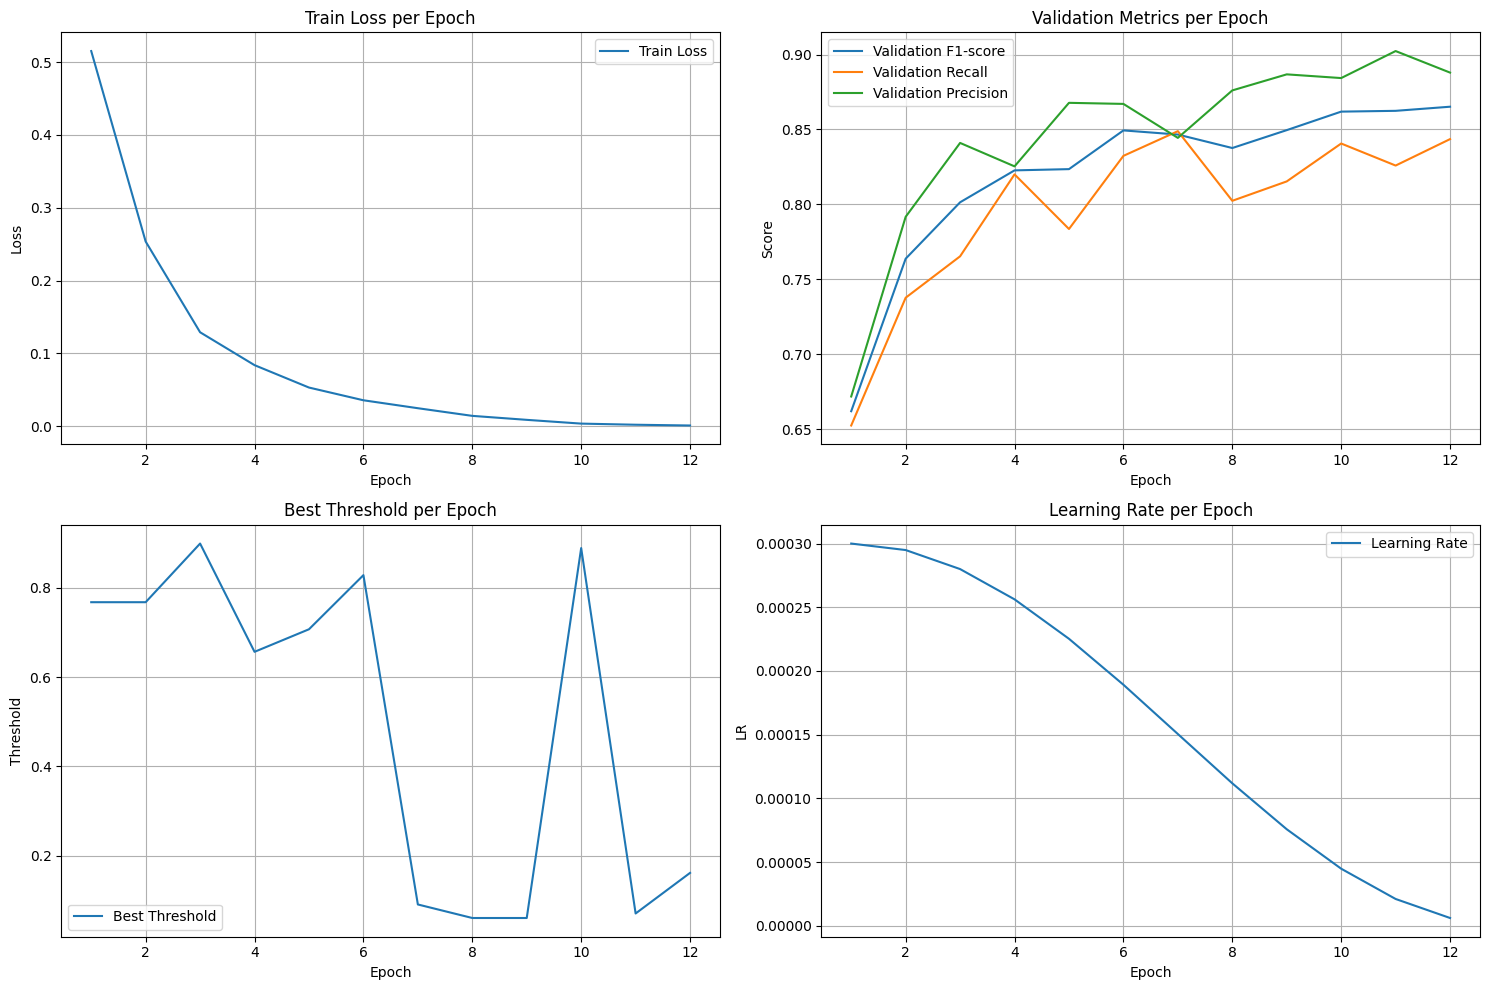

✅ Графики построены.


In [ ]:
# --- Построение графиков ---
print("\n📊 Построение графиков обучения...")
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.title('Train Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(epochs_range, history['val_f1'], label='Validation F1-score')
plt.plot(epochs_range, history['val_recall'], label='Validation Recall')
plt.plot(epochs_range, history['val_precision'], label='Validation Precision')
plt.title('Validation Metrics per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(epochs_range, history['val_best_thresh'], label='Best Threshold')
plt.title('Best Threshold per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Threshold')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(epochs_range, history['lr'], label='Learning Rate')
plt.title('Learning Rate per Epoch')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print("✅ Графики построены.")

In [ ]:
# Загружаем лучшие веса перед тестированием
trained_model.load_state_dict(torch.load('/content/drive/MyDrive/rgb+fft+lap.pth'))

In [ ]:
print("\n🚀 Шаг 5: Инференс с TTA на тестовых данных...")
test_files = os.listdir(TEST_IMG_PATH)
test_ids = [int(f.split('.')[0]) for f in test_files]
test_df = pd.DataFrame({'Id': test_ids, 'target_feature': 0})

test_dataset = DeepfakeDataset(df=test_df, img_dir=TEST_IMG_PATH, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

trained_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_predictions = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)

        # ВАЖНО: применяем TTA только для RGB ветки
        logits = trained_model(images, apply_tta_rgb=False)

        probs = torch.sigmoid(logits)
        preds = (probs >= best_threshold).int()
        test_predictions.extend(preds.cpu().numpy())

submission_df = pd.DataFrame({'Id': test_ids, 'target_feature': test_predictions})
submission_df = submission_df.sort_values('Id').reset_index(drop=True)
submission_df.to_csv('submission2.csv', index=False)

print("✅ Файл 'submission.csv' успешно создан и готов к отправке!")


🚀 Шаг 5: Инференс с TTA на тестовых данных...
✅ Файл 'submission.csv' успешно создан и готов к отправке!


# Генерация .parquet файлов

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# --- 1. НАСТРОЙКИ ---
MODEL_NAME = 'RGB_FFT_LAP'
WEIGHTS_PATH = '/content/drive/MyDrive/ALL_MODELS/weights/RGB+FFT+LAP/rgb+fft+lap.pth'
DRIVE_SAVE_PATH = f'/content/drive/MyDrive/ALL_MODELS/{MODEL_NAME}'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Path(DRIVE_SAVE_PATH).mkdir(parents=True, exist_ok=True)

# --- 2. ДАТАСЕТ (минимальный) ---
class SimpleInferenceDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row['Id'])
        img = Image.open(os.path.join(self.img_dir, f"{img_id}.jpg")).convert('RGB')
        target = float(row.get('target_feature', -1))
        return self.transform(img), img_id, torch.tensor(target, dtype=torch.float32)

val_transforms = T.Compose([
    T.Resize((320, 320)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 3. ИНИЦИАЛИЗАЦИЯ И ЗАГРУЗКА ---
print(f"Инициализация {MODEL_NAME}...")
model = DeepFakeDetector().to(DEVICE)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()

# --- 4. ФУНКЦИЯ ПРОГОНА ---
def run_predict(df, img_dir, is_test=False):
    ds = SimpleInferenceDataset(df, img_dir, val_transforms)
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)

    all_ids, all_logits, all_probs, all_targets = [], [], [], []

    with torch.no_grad():
        for imgs, ids, targets in tqdm(loader, desc="Inference"):
            imgs = imgs.to(DEVICE)

            outputs = model(imgs, apply_tta_rgb=False)
            logits = outputs.reshape(-1)
            probs = torch.sigmoid(logits)

            all_ids.extend(ids)
            all_logits.extend(logits.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            if not is_test: all_targets.extend(targets.numpy())

    res = pd.DataFrame({'id': all_ids, 'logit': all_logits, 'prob': all_probs})
    if not is_test: res['true_label'] = all_targets

    # Сортировка по ID
    def maybe_int(s): return int(s) if str(s).isdigit() else s
    res['id_sort'] = res['id'].apply(maybe_int)
    res = res.sort_values('id_sort').drop(columns=['id_sort']).reset_index(drop=True)
    return res
# --- 5. ПОДГОТОВКА СПИСКОВ И ЗАПУСК ---
full_df = pd.read_csv('/content/dataset_root/dataset/train_solution.csv', header=None, names=['Id', 'target_feature'])
full_df['Id'] = full_df['Id'].astype(str)
_, val_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['target_feature'])

test_path = Path('/content/dataset_root/dataset/test_images')
test_ids = [p.stem for p in test_path.glob('*.jpg')]
test_df = pd.DataFrame({'Id': test_ids})

print("\n--- Валидация ---")
val_res = run_predict(val_df, '/content/dataset_root/dataset/train_images')
val_res.to_parquet(f"{MODEL_NAME}_val_preds.parquet")
!cp {MODEL_NAME}_val_preds.parquet {DRIVE_SAVE_PATH}/

print("\n--- Тест ---")
test_res = run_predict(test_df, '/content/dataset_root/dataset/test_images', is_test=True)
test_res.to_parquet(f"{MODEL_NAME}_test_preds.parquet")
!cp {MODEL_NAME}_test_preds.parquet {DRIVE_SAVE_PATH}/

print(f"\nГотово! Результаты в {DRIVE_SAVE_PATH}")

Инициализация RGB_FFT_LAP...

--- Валидация ---


Inference: 100%|██████████| 313/313 [01:54<00:00,  2.73it/s]



--- Тест ---


Inference: 100%|██████████| 313/313 [01:58<00:00,  2.64it/s]


Готово! Результаты в /content/drive/MyDrive/ALL_MODELS/RGB_FFT_LAP
